In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score , confusion_matrix,ConfusionMatrixDisplay,  classification_report, auc, roc_curve,roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier


 - sbp: systolic blood pressure
 - tobacco: cumulative tobacco (kg)
 - ldl: low density lipoprotein cholesterol (It is a bad cholesterol. High level of ldl increases the risk of heart disease)
 - adiposity : the state of having excessive body fat,
 - famhist: family history of heart disease
 - typea: type A behavior
 - obesity
 - alcohol: current alcohol consumption
 - age
 - chd : the coronary heart disease (1/0)

In [2]:
# Load dataset
heart_df = pd.read_csv('heart-disease.csv', index_col=0)

# Reset index
heart_df = heart_df.reset_index()

heart_df

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1
...,...,...,...,...,...,...,...,...,...,...
457,214,0.40,5.98,31.72,Absent,64,28.45,0.00,58,0
458,182,4.20,4.41,32.10,Absent,52,28.61,18.72,52,1
459,108,3.00,1.59,15.23,Absent,40,20.09,26.64,55,0
460,118,5.40,11.61,30.79,Absent,64,27.35,23.97,40,0


In [3]:
# Check dataset structure
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 36.2+ KB


In [4]:
# Summary statistics
heart_df.describe()

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,138.326840,3.635649,4.740325,25.406732,53.103896,26.044113,17.044394,42.816017,0.346320
std,20.496317,4.593024,2.070909,7.780699,9.817534,4.213680,24.481059,14.608956,0.476313
min,101.000000,0.000000,0.980000,6.740000,13.000000,14.700000,0.000000,15.000000,0.000000
25%,124.000000,0.052500,3.282500,19.775000,47.000000,22.985000,0.510000,31.000000,0.000000
50%,134.000000,2.000000,4.340000,26.115000,53.000000,25.805000,7.510000,45.000000,0.000000
75%,148.000000,5.500000,5.790000,31.227500,60.000000,28.497500,23.892500,55.000000,1.000000
max,218.000000,31.200000,15.330000,42.490000,78.000000,46.580000,147.190000,64.000000,1.000000


The number of chd values:
 chd
0    302
1    160
Name: count, dtype: int64


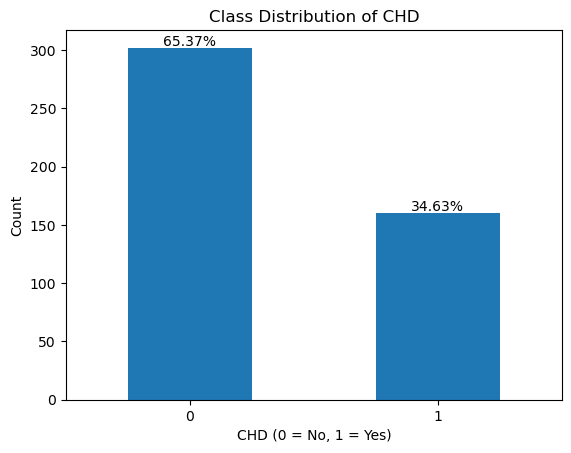

In [5]:
# Check class imbalance
counts = heart_df['chd'].value_counts()
print('The number of chd values:\n', counts)
total = counts.sum()

# Plot class distribution
ax = counts.plot(kind='bar')
plt.title('Class Distribution of CHD')
plt.xlabel('CHD (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Add proportions
for i, v in enumerate(counts):
    plt.text(i, v + 2, f'{v/total:.2%}', ha='center')

plt.xticks(rotation=0)
plt.show()

In [6]:
# Check missing values
heart_df.isnull().sum()

sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

In [7]:
# Encode categorical variable
heart_df.famhist.replace(('Present', 'Absent'), (1, -1), inplace=True)

C:\Users\zzian\AppData\Local\Temp\ipykernel_21336\402465802.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_df.famhist.replace(('Present', 'Absent'), (1, -1), inplace=True)
C:\Users\zzian\AppData\Local\Temp\ipykernel_21336\402465802.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart

Skewness in variables:
 sbp          1.180591
tobacco      2.079210
ldl          1.313104
adiposity   -0.214646
typea       -0.346438
obesity      0.905219
alcohol      2.312699
age         -0.381734
dtype: float64


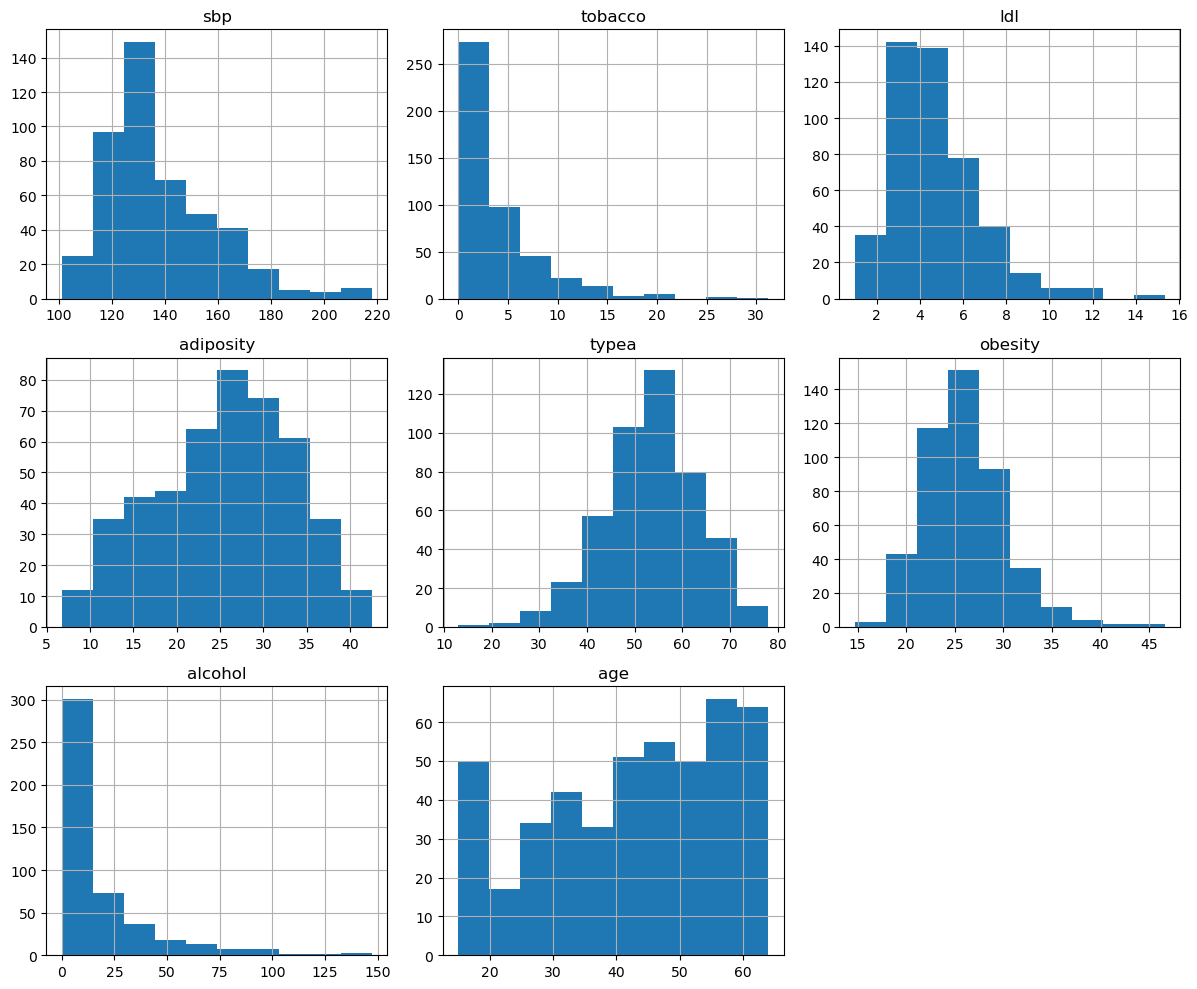

In [8]:
# Check skewness
var_int = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']
print('Skewness in variables:\n', heart_df[var_int].skew())

# Plot distributions
heart_df[var_int].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

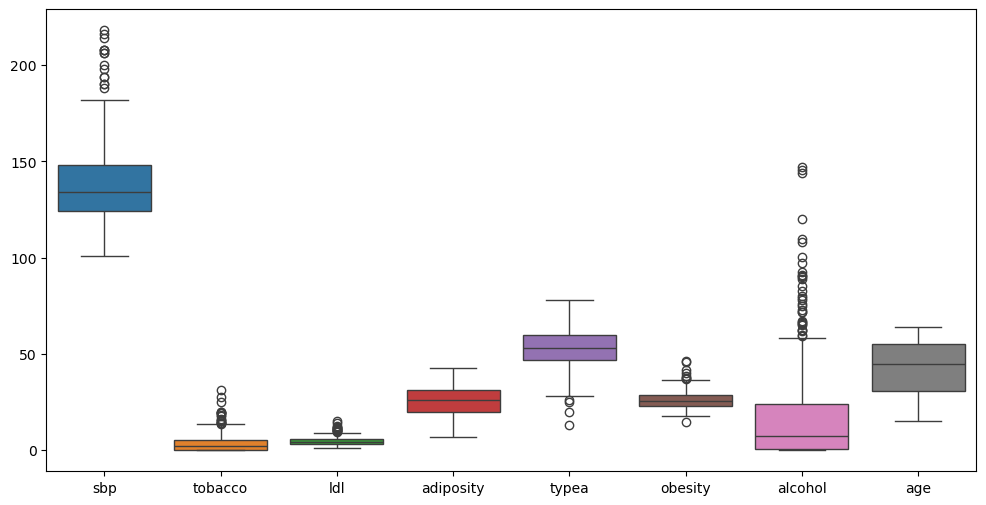

In [9]:
# Boxplot for numerical variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=heart_df[var_int])
plt.show()

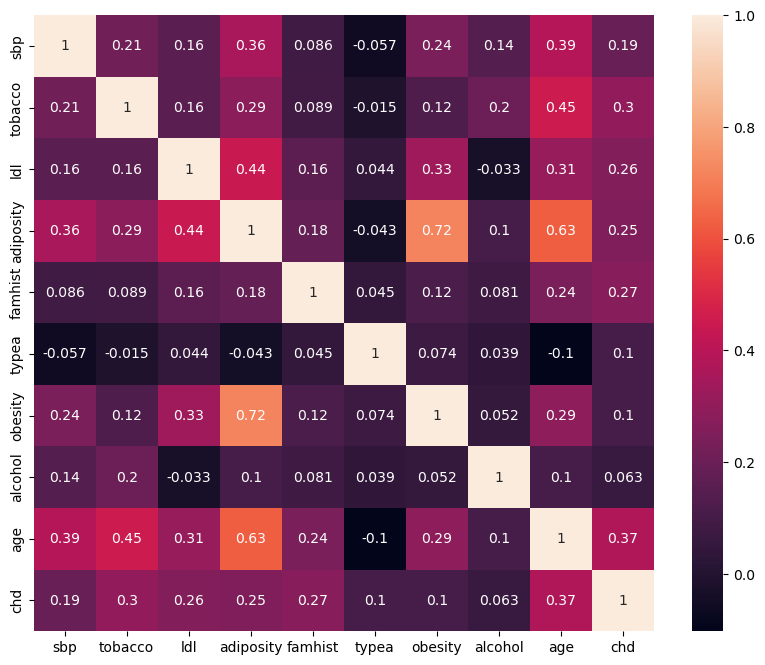

In [10]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(heart_df.corr(), annot=True)
plt.show()

- Age has the highest correlation with CHD (0.37), followed by tobacco (0.30).
- Famhist, LDL, and adiposity show similar correlations with CHD (0.25–0.27).

- A strong correlation is observed between obesity and adiposity (0.72).
- Age and adiposity are also highly correlated (0.63), while age and obesity show a weaker correlation (0.29).
- LDL and adiposity have a moderate correlation (0.44).

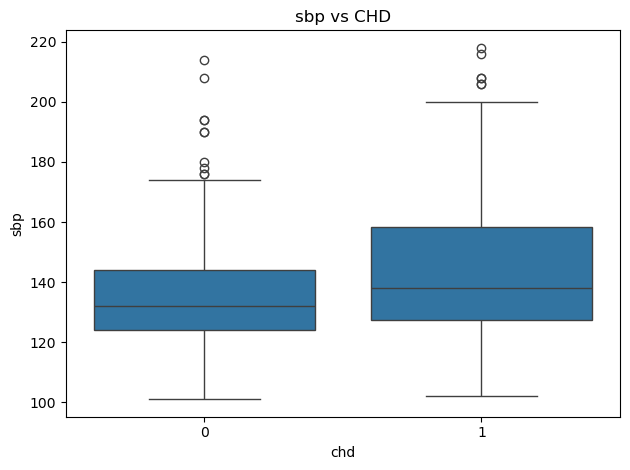

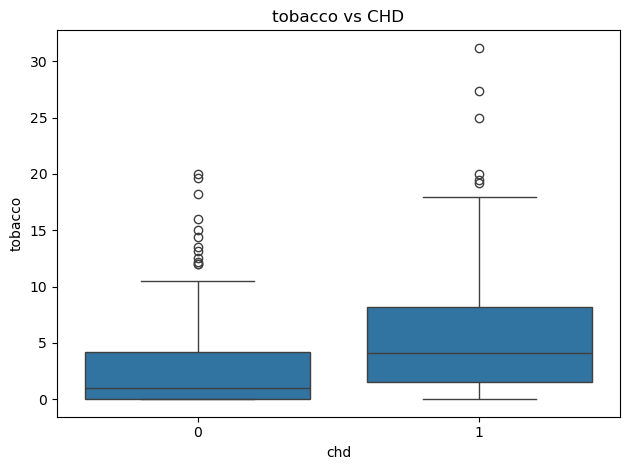

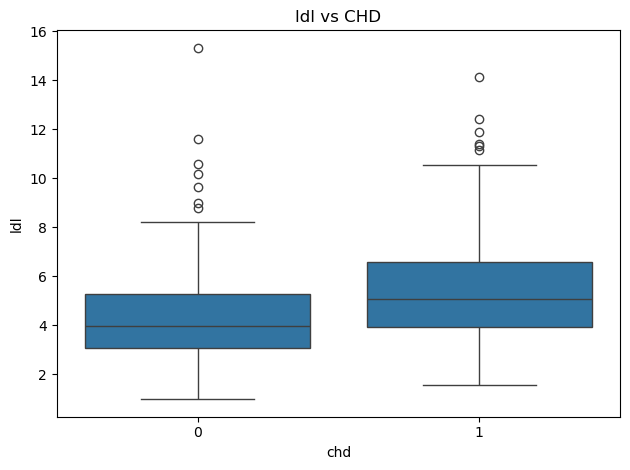

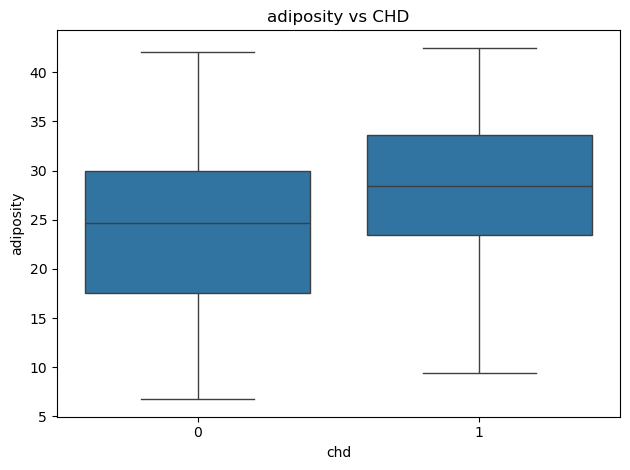

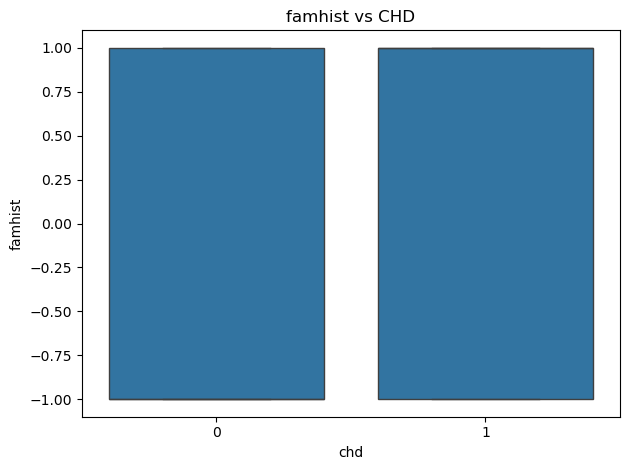

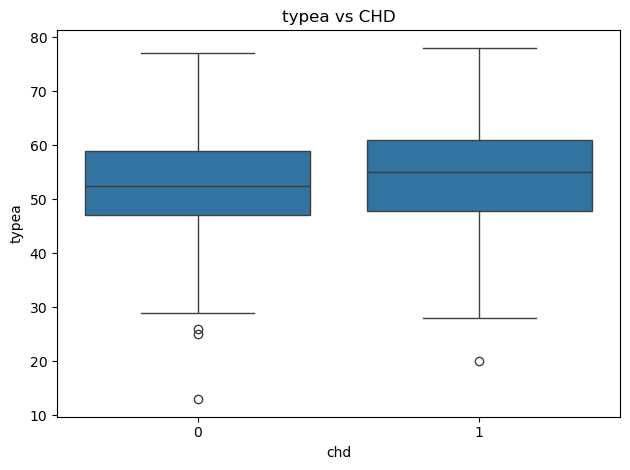

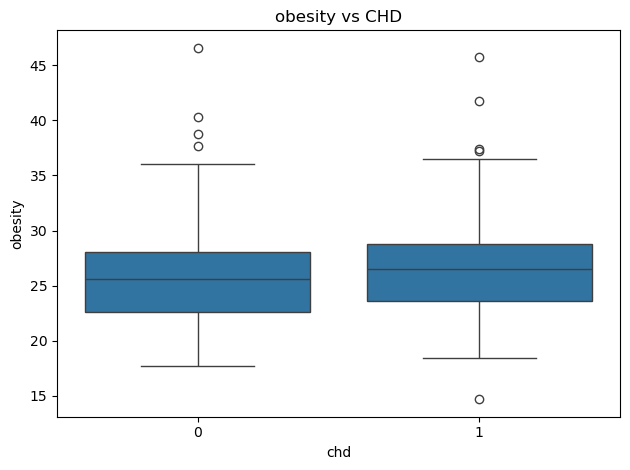

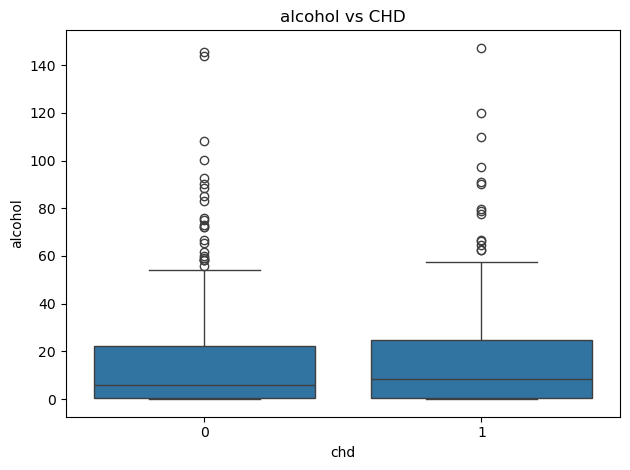

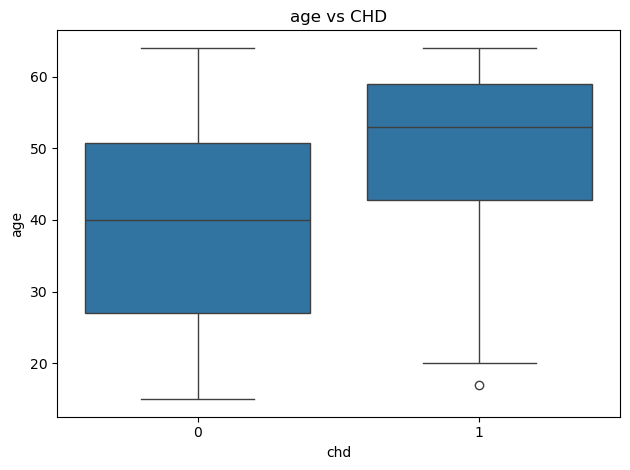

In [11]:
# Boxplots by CHD class
for col in heart_df.columns:
    if col != 'chd':
        sns.boxplot(x='chd', y=col, data=heart_df)
        plt.title(f'{col} vs CHD')
        plt.tight_layout()
        plt.show()

## Data Preprocessing

In [12]:
# Train-test split
X = heart_df.drop('chd', axis=1)
y = heart_df.chd
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=105)

# Standardize numerical features
scaler = StandardScaler()

# Numerical variables
var_int = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

# Apply scaling
X_train_sc[var_int] = scaler.fit_transform(X_train[var_int])
X_test_sc[var_int] = scaler.transform(X_test[var_int])

## Linear - Logistic Regression

In [13]:
# Train logistic regression (L2 penalty)
lr = LogisticRegression(penalty='l2')
lr.fit(X_train_sc, y_train)

# Prediction
lr_pred = lr.predict(X_test_sc)

In [14]:
# Evaluate logistic regression
print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_pred))
print('Logistic Regression Recall:', recall_score(y_test, lr_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, lr_pred))
print('\nClassification Report:\n', classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7266187050359713
Logistic Regression Recall: 0.5714285714285714

Confusion Matrix:
 [[73 17]
 [21 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79        90
           1       0.62      0.57      0.60        49

    accuracy                           0.73       139
   macro avg       0.70      0.69      0.69       139
weighted avg       0.72      0.73      0.72       139



## Linear-LDA

In [15]:
# Train LDA model
lda = LDA()
lda.fit(X_train_sc, y_train)

# Prediction
lda_pred = lda.predict(X_test_sc)

# Evaluate model
print('LDA Accuracy:', accuracy_score(y_test, lda_pred))
print('LDA Recall:', recall_score(y_test, lda_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, lda_pred))
print('\nClassification Report:\n', classification_report(y_test, lda_pred))

LDA Accuracy: 0.7194244604316546
LDA Recall: 0.5918367346938775

Confusion Matrix:
 [[71 19]
 [20 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.78        90
           1       0.60      0.59      0.60        49

    accuracy                           0.72       139
   macro avg       0.69      0.69      0.69       139
weighted avg       0.72      0.72      0.72       139



## NonLinear - Support Vector Machine

In [16]:
# SVM with hyperparameter tuning (RBF kernel)
tuned_parameter = [{'kernel': ['rbf'], 'gamma': [1, 1e-1, 1e-2, 1e-3, 1e-4], 'C': [1, 10, 100, 1000]}]

# Optimize for accuracy
svmCV_acc = GridSearchCV(SVC(probability=True), tuned_parameter, scoring='accuracy', cv=5)
svmCV_acc.fit(X_train_sc, y_train)
print('Best parameters (accuracy):')
print(svmCV_acc.best_params_)

# Optimize for recall
svmCV_rec = GridSearchCV(SVC(probability=True), tuned_parameter, scoring='recall', cv=5)
svmCV_rec.fit(X_train_sc, y_train)
print('\nBest parameters (recall):')
print(svmCV_rec.best_params_)

# Evaluate model (accuracy-optimized)
print('-' * 60)
svm_pred_acc = svmCV_acc.predict(X_test_sc)
print('SVM Accuracy:', accuracy_score(y_test, svm_pred_acc))
print('SVM Recall:', recall_score(y_test, svm_pred_acc))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, svm_pred_acc))
print('\nClassification Report:\n', classification_report(y_test, svm_pred_acc))

Best parameters (accuracy):
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best parameters (recall):
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
------------------------------------------------------------
SVM Accuracy: 0.7482014388489209
SVM Recall: 0.5510204081632653

Confusion Matrix:
 [[77 13]
 [22 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.81        90
           1       0.68      0.55      0.61        49

    accuracy                           0.75       139
   macro avg       0.73      0.70      0.71       139
weighted avg       0.74      0.75      0.74       139



In [17]:
# Evaluate model (recall-optimized)
svm_pred_rec = svmCV_rec.predict(X_test_sc)
print('SVM Accuracy:', accuracy_score(y_test, svm_pred_rec))
print('SVM Recall:', recall_score(y_test, svm_pred_rec))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, svm_pred_rec))
print('\nClassification Report:\n', classification_report(y_test, svm_pred_rec))

SVM Accuracy: 0.7482014388489209
SVM Recall: 0.5510204081632653

Confusion Matrix:
 [[77 13]
 [22 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.81        90
           1       0.68      0.55      0.61        49

    accuracy                           0.75       139
   macro avg       0.73      0.70      0.71       139
weighted avg       0.74      0.75      0.74       139



## Non-linear-Naive Bayes

In [18]:
# Train Gaussian Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_sc, y_train)

# Prediction
nb_pred = nb.predict(X_test_sc)

# Evaluate model
print('Naive Bayes Accuracy:', accuracy_score(y_test, nb_pred))
print('Naive Bayes Recall:', recall_score(y_test, nb_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, nb_pred))
print('\nClassification Report:\n', classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.697841726618705
Naive Bayes Recall: 0.5510204081632653

Confusion Matrix:
 [[70 20]
 [22 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77        90
           1       0.57      0.55      0.56        49

    accuracy                           0.70       139
   macro avg       0.67      0.66      0.67       139
weighted avg       0.70      0.70      0.70       139



## Non-Linear-QDA

In [19]:
# Train QDA model
qda = QDA()
qda.fit(X_train_sc, y_train)

# Prediction
qda_pred = qda.predict(X_test_sc)

# Evaluate model
print('QDA Accuracy:', accuracy_score(y_test, qda_pred))
print('QDA Recall:', recall_score(y_test, qda_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, qda_pred))
print('\nClassification Report:\n', classification_report(y_test, qda_pred))

QDA Accuracy: 0.697841726618705
QDA Recall: 0.5510204081632653

Confusion Matrix:
 [[70 20]
 [22 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77        90
           1       0.57      0.55      0.56        49

    accuracy                           0.70       139
   macro avg       0.67      0.66      0.67       139
weighted avg       0.70      0.70      0.70       139



## Non-Linear-Decision Tree

In [20]:
# Decision tree with hyperparameter tuning - alpha (pruning)
tuned_parameter = [{'ccp_alpha': [1, 0.1, 0.01, 0.001, 0.0001]}]

# Optimize for accuracy
treeCV_acc = GridSearchCV(DecisionTreeClassifier(random_state=67),
                          tuned_parameter, scoring='accuracy', cv=5)
treeCV_acc.fit(X_train_sc, y_train)
print('Best parameters (accuracy):')
print(treeCV_acc.best_params_)

# Optimize for recall
treeCV_rec = GridSearchCV(DecisionTreeClassifier(random_state=67),
                          tuned_parameter, scoring='recall', cv=5)
treeCV_rec.fit(X_train_sc, y_train)
print('\nBest parameters (recall):')
print(treeCV_rec.best_params_)

# Evaluate model (accuracy-optimized)
tree_pred_acc = treeCV_acc.predict(X_test_sc)
print('-' * 60)
print('Decision Tree Accuracy:', accuracy_score(y_test, tree_pred_acc))
print('Decision Tree Recall:', recall_score(y_test, tree_pred_acc))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, tree_pred_acc))
print('\nClassification Report:\n', classification_report(y_test, tree_pred_acc))

Best parameters (accuracy):
{'ccp_alpha': 0.01}

Best parameters (recall):
{'ccp_alpha': 0.001}
------------------------------------------------------------
Decision Tree Accuracy: 0.7338129496402878
Decision Tree Recall: 0.5306122448979592

Confusion Matrix:
 [[76 14]
 [23 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.80        90
           1       0.65      0.53      0.58        49

    accuracy                           0.73       139
   macro avg       0.71      0.69      0.69       139
weighted avg       0.73      0.73      0.73       139



In [21]:
# Evaluate model (recall-optimized)
tree_pred_rec = treeCV_rec.predict(X_test_sc)
print('Decision Tree Accuracy:', accuracy_score(y_test, tree_pred_rec))
print('Decision Tree Recall:', recall_score(y_test, tree_pred_rec))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, tree_pred_rec))
print('\nClassification Report:\n', classification_report(y_test, tree_pred_rec))

Decision Tree Accuracy: 0.6402877697841727
Decision Tree Recall: 0.5306122448979592

Confusion Matrix:
 [[63 27]
 [23 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.70      0.72        90
           1       0.49      0.53      0.51        49

    accuracy                           0.64       139
   macro avg       0.61      0.62      0.61       139
weighted avg       0.65      0.64      0.64       139



## Non-linear : Random Forest

In [22]:
# Random forest with hyperparameter tuning
tuned_parameter_RF = [{'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9, 'sqrt']}]

# Optimize for accuracy
rfCV_acc = GridSearchCV(
    RandomForestClassifier(n_estimators=500, bootstrap=True, oob_score=True, random_state=67),
    tuned_parameter_RF, scoring='accuracy', cv=5)

rfCV_acc.fit(X_train_sc, y_train)
print('Best parameters (accuracy):')
print(rfCV_acc.best_params_)

# Optimize for recall
rfCV_rec = GridSearchCV(
    RandomForestClassifier(n_estimators=500, bootstrap=True, oob_score=True, random_state=67),
    tuned_parameter_RF, scoring='recall', cv=5)

rfCV_rec.fit(X_train_sc, y_train)
print('\nBest parameters (recall):')
print(rfCV_rec.best_params_)

# Evaluate model (accuracy-optimized)
rf_pred_acc = rfCV_acc.predict(X_test_sc)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred_acc))
print('Random Forest Recall:', recall_score(y_test, rf_pred_acc))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, rf_pred_acc))
print('\nClassification Report:\n', classification_report(y_test, rf_pred_acc))

Best parameters (accuracy):
{'max_features': 1}

Best parameters (recall):
{'max_features': 7}
Random Forest Accuracy: 0.6906474820143885
Random Forest Recall: 0.40816326530612246

Confusion Matrix:
 [[76 14]
 [29 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.84      0.78        90
           1       0.59      0.41      0.48        49

    accuracy                           0.69       139
   macro avg       0.66      0.63      0.63       139
weighted avg       0.68      0.69      0.67       139



In [23]:
# Evaluate model (recall-optimized)
rf_pred_rec = rfCV_rec.predict(X_test_sc)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred_rec))
print('Random Forest Recall:', recall_score(y_test, rf_pred_rec))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, rf_pred_rec))
print('\nClassification Report:\n', classification_report(y_test, rf_pred_rec))

Random Forest Accuracy: 0.6474820143884892
Random Forest Recall: 0.40816326530612246

Confusion Matrix:
 [[70 20]
 [29 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74        90
           1       0.50      0.41      0.45        49

    accuracy                           0.65       139
   macro avg       0.60      0.59      0.60       139
weighted avg       0.63      0.65      0.64       139



## Non-linear : AdaBoost

In [24]:
# AdaBoost with hyperparameter tuning
tuned_parameter_ada = [{'learning_rate': [0.001, 0.01, 0.1, 1]}]

# Optimize for accuracy
adaCV_acc = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                       n_estimators=100, random_state=67),
    tuned_parameter_ada, scoring='accuracy', cv=5)
adaCV_acc.fit(X_train_sc, y_train)
print('Best parameters (accuracy):')
print(adaCV_acc.best_params_)

# Optimize for recall
adaCV_rec = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                       n_estimators=100, random_state=67),
    tuned_parameter_ada, scoring='recall', cv=5)

adaCV_rec.fit(X_train_sc, y_train)
print('\nBest parameters (recall):')
print(adaCV_rec.best_params_)

# Evaluate model (accuracy-optimized)
ada_pred_acc = adaCV_acc.predict(X_test_sc)
print('-' * 60)
print('AdaBoost Accuracy:', accuracy_score(y_test, ada_pred_acc))
print('AdaBoost Recall:', recall_score(y_test, ada_pred_acc))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, ada_pred_acc))
print('\nClassification Report:\n', classification_report(y_test, ada_pred_acc))

Best parameters (accuracy):
{'learning_rate': 0.001}

Best parameters (recall):
{'learning_rate': 0.1}
------------------------------------------------------------
AdaBoost Accuracy: 0.7338129496402878
AdaBoost Recall: 0.5306122448979592

Confusion Matrix:
 [[76 14]
 [23 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.80        90
           1       0.65      0.53      0.58        49

    accuracy                           0.73       139
   macro avg       0.71      0.69      0.69       139
weighted avg       0.73      0.73      0.73       139



In [25]:
# Evaluate model (recall-optimized)
ada_pred_rec = adaCV_rec.predict(X_test_sc)
print('-' * 60)
print('AdaBoost Accuracy:', accuracy_score(y_test, ada_pred_rec))
print('AdaBoost Recall:', recall_score(y_test, ada_pred_rec))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, ada_pred_rec))
print('\nClassification Report:\n', classification_report(y_test, ada_pred_rec))

------------------------------------------------------------
AdaBoost Accuracy: 0.7266187050359713
AdaBoost Recall: 0.5306122448979592

Confusion Matrix:
 [[75 15]
 [23 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80        90
           1       0.63      0.53      0.58        49

    accuracy                           0.73       139
   macro avg       0.70      0.68      0.69       139
weighted avg       0.72      0.73      0.72       139



In [26]:
# Compute predicted probabilities  (Target : Accuracy)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
y_prob_svm_acc = svmCV_acc.predict_proba(X_test_sc)[:, 1]
y_prob_svm_rec = svmCV_rec.predict_proba(X_test_sc)[:, 1]
y_prob_lda = lda.predict_proba(X_test_sc)[:, 1]
y_prob_nb = nb.predict_proba(X_test_sc)[:, 1]
y_prob_qda = qda.predict_proba(X_test_sc)[:, 1]
y_prob_tree_acc = treeCV_acc.predict_proba(X_test_sc)[:, 1]
y_prob_tree_rec = treeCV_rec.predict_proba(X_test_sc)[:, 1]
y_prob_rf_acc = rfCV_acc.predict_proba(X_test_sc)[:, 1]
y_prob_rf_rec = rfCV_rec.predict_proba(X_test_sc)[:, 1]
y_prob_ada_acc = adaCV_acc.predict_proba(X_test_sc)[:, 1]
y_prob_ada_rec = adaCV_rec.predict_proba(X_test_sc)[:, 1]

# Store predictions and probabilities (Target : Accuracy)
model_result_acc = {
    'Logistic Regression': (lr_pred, y_prob_lr),
    'SVM (acc)': (svm_pred_acc, y_prob_svm_acc),
    'LDA': (lda_pred, y_prob_lda),
    'Naive Bayes': (nb_pred, y_prob_nb),
    'QDA': (qda_pred, y_prob_qda),
    'Decision Tree (acc)': (tree_pred_acc, y_prob_tree_acc),
    'Random Forest (acc)': (rf_pred_acc, y_prob_rf_acc),
    'AdaBoost (acc)': (ada_pred_acc, y_prob_ada_acc)}

# Compute performance metrics  (Target : Accuracy)
results_acc = []

for model, (pred, prob) in model_result_acc.items():
    acc = accuracy_score(y_test, pred)
    auc_score_acc = roc_auc_score(y_test, prob)

    results_acc.append({
        'Model': model,
        'Accuracy': f'{acc:.3f}',
        'AUC': f'{auc_score_acc:.3f}'
    })

# Display results (Target : Accuracy)
df_results = pd.DataFrame(results_acc)
print(df_results.sort_values('Accuracy', ascending=False))
print('-' * 60)
print(df_results.sort_values('AUC', ascending=False))

                 Model Accuracy    AUC
1            SVM (acc)    0.748  0.780
5  Decision Tree (acc)    0.734  0.729
7       AdaBoost (acc)    0.734  0.688
0  Logistic Regression    0.727  0.776
2                  LDA    0.719  0.773
3          Naive Bayes    0.698  0.741
4                  QDA    0.698  0.706
6  Random Forest (acc)    0.691  0.742
------------------------------------------------------------
                 Model Accuracy    AUC
1            SVM (acc)    0.748  0.780
0  Logistic Regression    0.727  0.776
2                  LDA    0.719  0.773
6  Random Forest (acc)    0.691  0.742
3          Naive Bayes    0.698  0.741
5  Decision Tree (acc)    0.734  0.729
4                  QDA    0.698  0.706
7       AdaBoost (acc)    0.734  0.688


In [27]:
# Store predictions and probabilities (Target : Recall)
model_result_rec = {
    'Logistic Regression': (lr_pred, y_prob_lr),
    'SVM (rec)': (svm_pred_rec, y_prob_svm_rec),
    'LDA': (lda_pred, y_prob_lda),
    'Naive Bayes': (nb_pred, y_prob_nb),
    'QDA': (qda_pred, y_prob_qda),
    'Decision Tree (rec)': (tree_pred_rec, y_prob_tree_rec),
    'Random Forest (rec)': (rf_pred_rec, y_prob_rf_rec),
    'AdaBoost (rec)': (ada_pred_rec, y_prob_ada_rec),
}

# Compute performance metrics (Target : Recall)
results_rec = []

for model, (pred, prob) in model_result_rec.items():
    rec = recall_score(y_test, pred)
    auc_score_rec = roc_auc_score(y_test, prob)

    results_rec.append({
        'Model': model,
        'Recall': f'{rec:.3f}',
        'AUC': f'{auc_score_rec:.3f}'
    })

# Display results (Target : Recall)
df_results_rec = pd.DataFrame(results_rec)
print(df_results_rec.sort_values('Recall', ascending=False))
print('-' * 60)
print(df_results_rec.sort_values('AUC', ascending=False))

                 Model Recall    AUC
2                  LDA  0.592  0.773
0  Logistic Regression  0.571  0.776
1            SVM (rec)  0.551  0.766
3          Naive Bayes  0.551  0.741
4                  QDA  0.551  0.706
5  Decision Tree (rec)  0.531  0.615
7       AdaBoost (rec)  0.531  0.757
6  Random Forest (rec)  0.408  0.721
------------------------------------------------------------
                 Model Recall    AUC
0  Logistic Regression  0.571  0.776
2                  LDA  0.592  0.773
1            SVM (rec)  0.551  0.766
7       AdaBoost (rec)  0.531  0.757
3          Naive Bayes  0.551  0.741
6  Random Forest (rec)  0.408  0.721
4                  QDA  0.551  0.706
5  Decision Tree (rec)  0.531  0.615


## Model Comparison (Accuracy): Confusion Matrix and AUC-ROC Curve for the Best Model and the Baseline Model

- SVM achieves the highest accuracy and outperforms logistic regression.
- We compare SVM and logistic regression using the confusion matrix and the AUC-ROC curve.

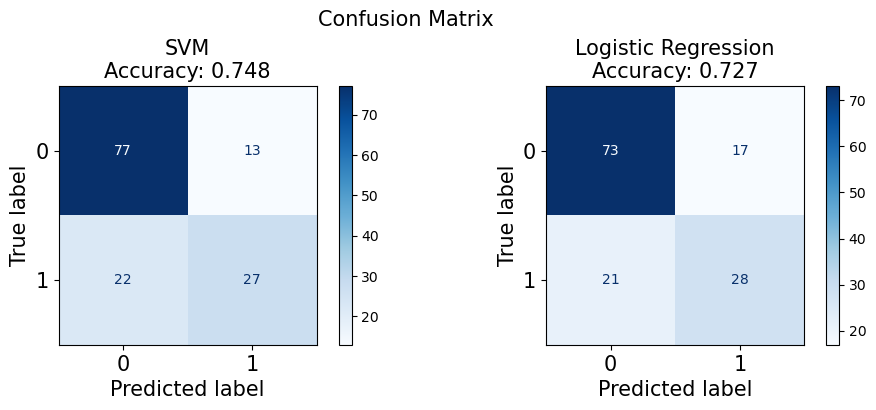

In [28]:
# Confusion matrices (accuracy comparison)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# SVM (accuracy-optimized)
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred_acc, ax=ax[0], cmap='Blues')
ax[0].set_title(f"SVM\nAccuracy: {accuracy_score(y_test, svm_pred_acc):.3f}", fontsize=15)

# Logistic regression (baseline)
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=ax[1], cmap='Blues')
ax[1].set_title(f"Logistic Regression\nAccuracy: {accuracy_score(y_test, lr_pred):.3f}", fontsize=15)

# Axis formatting
for a in ax:
    a.set_xlabel('Predicted label', fontsize=15)
    a.set_ylabel('True label', fontsize=15)
    a.tick_params(axis='both', labelsize=15)

fig.suptitle('Confusion Matrix', fontsize=15)
plt.tight_layout()
plt.show()

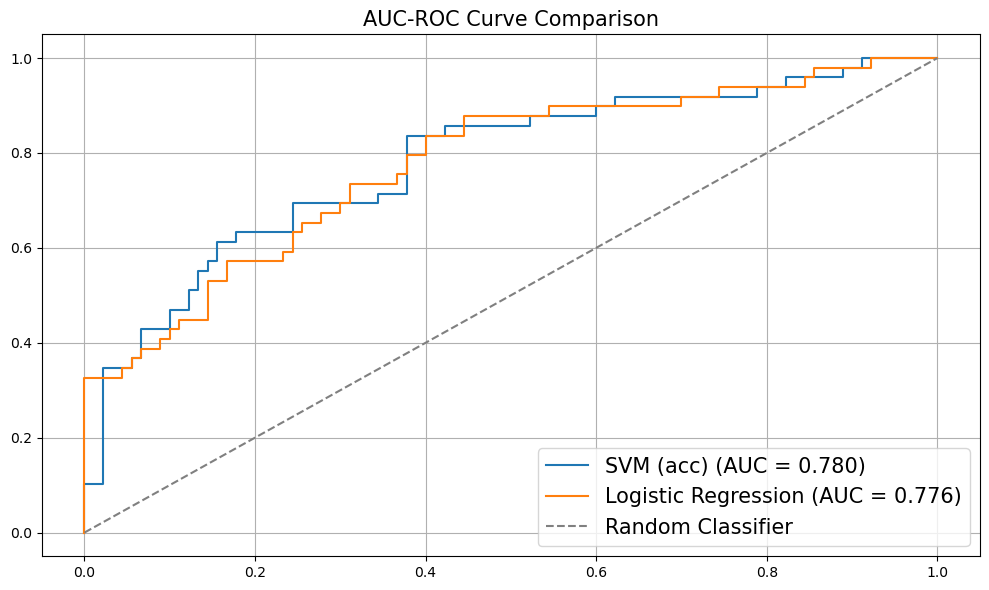

In [29]:
# ROC curve comparison (Accuracy)
fig, ax = plt.subplots(figsize=(10, 6))

# SVM (accuracy-optimized)
y_prob_svm_acc = svmCV_acc.predict_proba(X_test_sc)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm_acc)
auc_svm = auc(fpr_svm, tpr_svm)
ax.plot(fpr_svm, tpr_svm, label=f"SVM (acc) (AUC = {auc_svm:.3f})")

# Logistic regression
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Classifier')

ax.set_title('AUC-ROC Curve Comparison', fontsize=15)
ax.legend(loc='lower right', fontsize=15)
plt.tight_layout()
plt.grid()
plt.show()

## Model Comparison (Recall): Confusion Matrix and AUC-ROC Curve for the Best Model and the Baseline Model

- LDA achieves the highest recall and outperforms logistic regression.
- We compare LDA and logistic regression using the confusion matrix and the AUC-ROC curve.

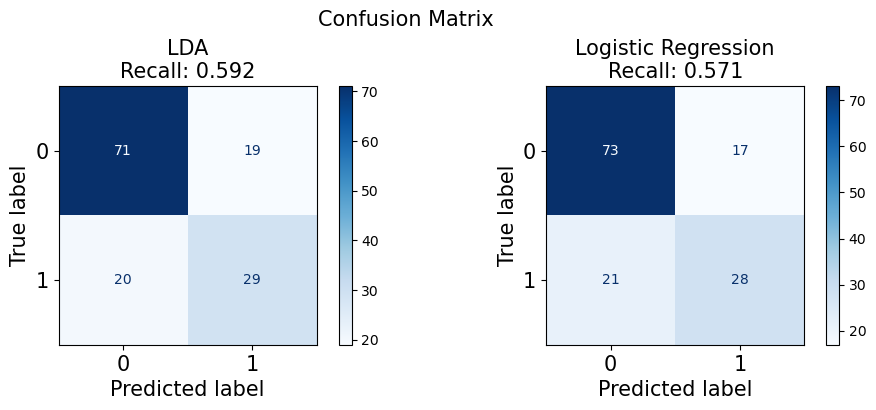

In [30]:
# Confusion matrices (recall comparison)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# LDA
ConfusionMatrixDisplay.from_predictions(y_test, lda_pred, ax=ax[0], cmap='Blues')
ax[0].set_title(f"LDA\nRecall: {recall_score(y_test, lda_pred):.3f}", fontsize=15)

# Logistic regression (baseline)
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=ax[1], cmap='Blues')
ax[1].set_title(f"Logistic Regression\nRecall: {recall_score(y_test, lr_pred):.3f}", fontsize=15)

# Axis formatting
for a in ax:
    a.set_xlabel('Predicted label', fontsize=15)
    a.set_ylabel('True label', fontsize=15)
    a.tick_params(axis='both', labelsize=15)

fig.suptitle('Confusion Matrix', fontsize=15)
plt.tight_layout()
plt.show()

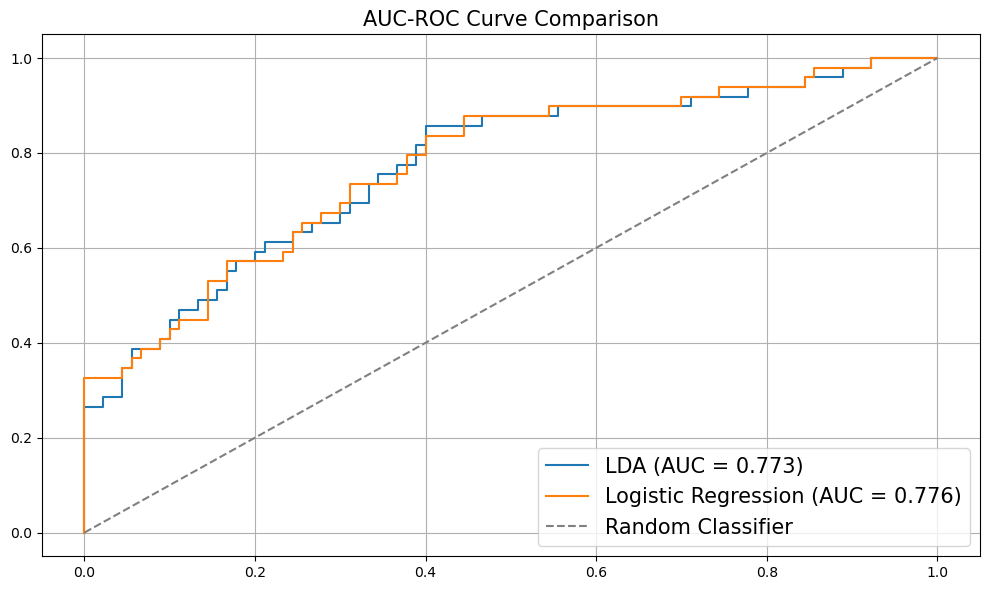

In [31]:
# ROC curve comparison (recall)
fig, ax = plt.subplots(figsize=(10, 6))

# LDA
y_prob_lda = lda.predict_proba(X_test_sc)[:, 1]
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_lda)
auc_lda = auc(fpr_lda, tpr_lda)
ax.plot(fpr_lda, tpr_lda, label=f"LDA (AUC = {auc_lda:.3f})")

# Logistic regression (baseline)
ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Classifier')

ax.set_title('AUC-ROC Curve Comparison', fontsize=15)
ax.legend(loc='lower right', fontsize=15)
plt.tight_layout()
plt.grid()
plt.show()